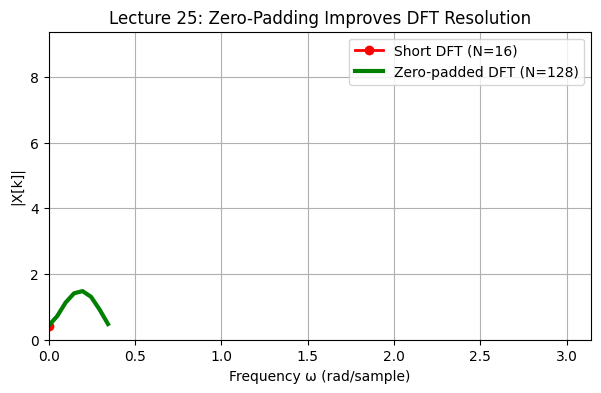

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 25: Zero-Padding & DFT Resolution
# -----------------------------

# Signal: single sinusoid not exactly on DFT bin
N = 16
n = np.arange(N)
omega0 = 0.35 * np.pi
x = np.cos(omega0 * n)

# DFT without zero-padding
X = np.abs(np.fft.fft(x))
freq = np.linspace(0, 2*np.pi, len(X), endpoint=False)

# DFT with zero-padding
Nz = 128
Xz = np.abs(np.fft.fft(x, Nz))
freq_z = np.linspace(0, 2*np.pi, Nz, endpoint=False)

# Plot setup
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(0, np.pi)
ax.set_ylim(0, max(Xz) + 1)
ax.grid(True)
ax.set_title("Lecture 25: Zero-Padding Improves DFT Resolution")
ax.set_xlabel("Frequency ω (rad/sample)")
ax.set_ylabel("|X[k]|")

# Animated spectra
short_line, = ax.plot([], [], 'r-o', lw=2, label="Short DFT (N=16)")
pad_line,   = ax.plot([], [], 'g', lw=3, label="Zero-padded DFT (N=128)")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture-9 style)
# -----------------------------
def update(frame):
    # progressively reveal frequency bins
    short_bins = min(frame + 1, len(X) // 2)
    pad_bins   = min(8 * (frame + 1), Nz // 2)

    short_line.set_data(freq[:short_bins], X[:short_bins])
    pad_line.set_data(freq_z[:pad_bins], Xz[:pad_bins])

    return short_line, pad_line

frames = len(X) // 2
anim = FuncAnimation(fig, update, frames=frames, interval=500)

HTML(anim.to_jshtml())

🔴 The short DFT shows only a few frequency samples
🟢 The zero‑padded DFT fills in a smooth curve
Both spectra peak at the same frequency
The padded version simply makes the peak easier to see